###**Objective**
To assess understanding of collaborative filtering methods and ability to generate and interpret recommendations in a business context.

###**Loading the data**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
df = pd.read_csv("/content/drive/MyDrive/BUSA-710 Prof.Mittal/book_reviews.csv")

In [5]:
df.shape

(793, 3)

In [6]:
df.head(10)

,userID,bookID,rating
0,1,1,5
1,1,2,5
2,1,3,2
3,1,4,3
4,1,5,5
5,1,6,3
6,1,7,2
7,1,8,2
8,1,9,5
9,1,10,2


In [7]:
for column in df.columns:
    print(f"Unique values in column '{column}':")
    print(df[column].unique())
    print("\n")

Unique values in column 'userID':
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50]


Unique values in column 'bookID':
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 19 20 18]


Unique values in column 'rating':
[5 2 3 4 1]




The data consist of 50 unique user and there are 20 unique book which the company has and the rating range from 1-5

In [8]:
df.describe()

,userID,bookID,rating
count,793.000000,793.000000,793.000000
mean,25.223203,10.363178,2.992434
std,14.594757,5.723358,1.401638
min,1.000000,1.000000,1.000000
25%,13.000000,6.000000,2.000000
50%,25.000000,10.000000,3.000000
75%,38.000000,15.000000,4.000000
max,50.000000,20.000000,5.000000


###**Calculating sparsity of User-Item Matrix**

Formula: Sparsity=1 - (Number of Non-Null entries/Total Possible Entries)​

Interpreting Sparsity:

High Sparsity (e.g., > 90%): Most user-item pairs have no ratings, making recommendations challenging.

Low Sparsity (e.g., < 50%): Many ratings are available, making it easier to find similar users or items.

In [9]:
num_users = df['userID'].nunique()
num_book = df['bookID'].nunique()

total_possible_entries = num_users * num_book

# Actual number of ratings (non-null entries)
num_ratings = df.shape[0]

# Calculate sparsity
sparsity = 1 - (num_ratings / total_possible_entries)

print(f'Total Users: {num_users}')
print(f'Total Books: {num_book}')
print(f'Total Possible Entries (User x book): {total_possible_entries}')
print(f'Number of Ratings: {num_ratings}')
print(f'Sparsity of the User-Item Matrix: {sparsity:.4f} or {sparsity * 100:.2f}%')

Total Users: 50
Total Books: 20
Total Possible Entries (User x book): 1000
Number of Ratings: 793
Sparsity of the User-Item Matrix: 0.2070 or 20.70%


The dataset is low in sparsity( lesse then 0.5 or 50%) making it easy for recommendation or find similarity. We can use KNN Mean meathod on low sparse data for recommendation it work better on low sparse data then SVD. However, we will calculate RSME for each model and give our best option for recommendation.

/tmp/ipykernel_961/471402621.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


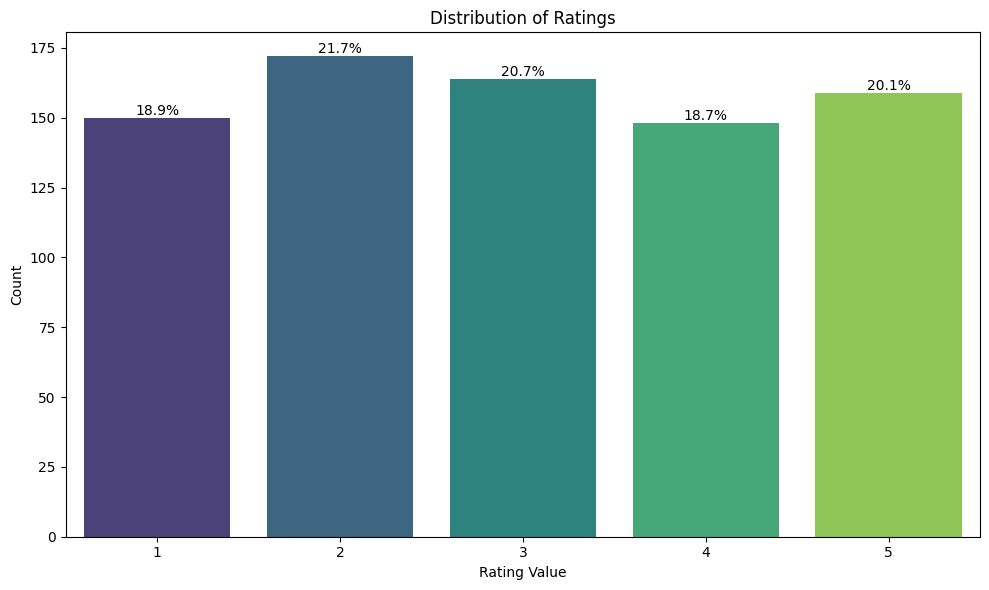

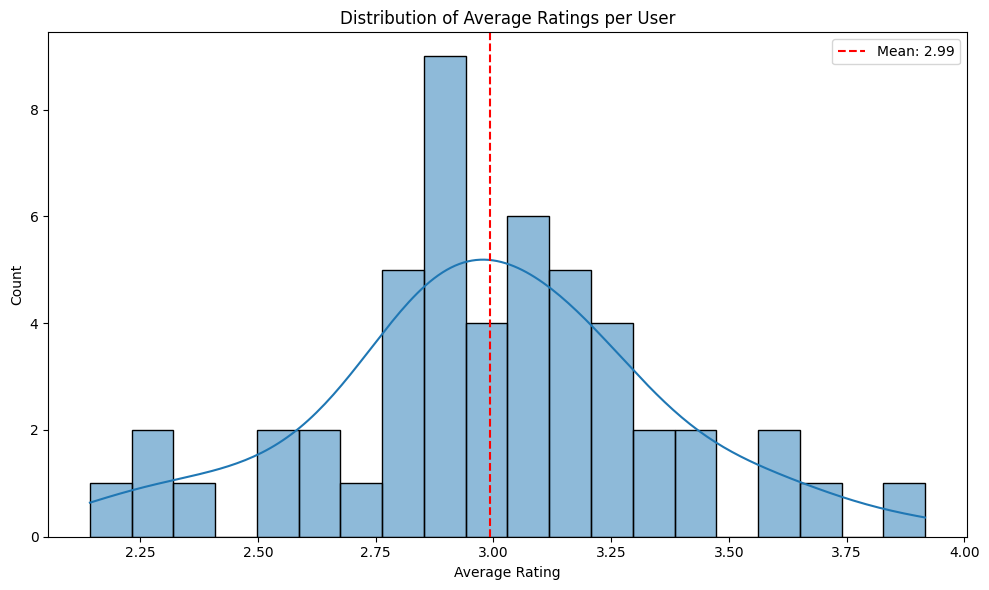

In [10]:
plt.figure(figsize=(10, 6))

# Plot the distribution of ratings
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating Value')
plt.ylabel('Count')

# Add percentage labels on top of the bars
total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    plt.gca().annotate(percentage,
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Add a box plot to show rating distribution by user
plt.figure(figsize=(10, 6))
user_ratings = df.groupby('userID')['rating'].mean().reset_index() # Corrected 'userId' to 'userID'
sns.histplot(user_ratings['rating'], kde=True, bins=20)
plt.axvline(user_ratings['rating'].mean(), color='r', linestyle='--',
           label=f'Mean: {user_ratings["rating"].mean():.2f}')
plt.title('Distribution of Average Ratings per User')
plt.xlabel('Average Rating')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

###**2. Implement Collaborative Filtering Methods**

In [11]:
# Create a user-item matrix
user_book_matrix = df.pivot(index='userID', columns='bookID', values='rating').fillna(0)

In [12]:
user_book_matrix

bookID,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
userID,,,,,,,,,,,,,,,,,,,,
1,5.0,5.0,2.0,3.0,5.0,3.0,2.0,2.0,5.0,2.0,4.0,3.0,2.0,4.0,3.0,4.0,3.0,0.0,1.0,4.0
2,0.0,2.0,5.0,4.0,4.0,3.0,0.0,4.0,2.0,5.0,0.0,2.0,4.0,4.0,5.0,2.0,2.0,0.0,5.0,5.0
3,1.0,4.0,3.0,3.0,3.0,2.0,1.0,2.0,5.0,3.0,3.0,3.0,2.0,3.0,2.0,5.0,1.0,4.0,0.0,5.0
4,5.0,3.0,4.0,0.0,0.0,4.0,0.0,3.0,4.0,1.0,3.0,4.0,3.0,3.0,5.0,2.0,3.0,1.0,1.0,4.0
5,2.0,5.0,1.0,2.0,5.0,1.0,2.0,2.0,0.0,4.0,3.0,5.0,3.0,0.0,1.0,5.0,0.0,4.0,3.0,0.0
6,4.0,0.0,2.0,0.0,1.0,2.0,4.0,1.0,1.0,4.0,3.0,1.0,3.0,0.0,1.0,3.0,0.0,4.0,1.0,5.0
7,2.0,3.0,1.0,4.0,5.0,3.0,1.0,3.0,5.0,3.0,5.0,4.0,1.0,5.0,4.0,1.0,4.0,0.0,0.0,0.0
8,1.0,0.0,5.0,4.0,0.0,5.0,1.0,2.0,2.0,0.0,2.0,2.0,2.0,0.0,1.0,5.0,2.0,0.0,0.0,0.0
9,1.0,4.0,4.0,0.0,2.0,3.0,5.0,0.0,0.0,2.0,0.0,4.0,5.0,4.0,4.0,0.0,3.0,4.0,2.0,3.0


Business Interpretation of the User-Item Matrix

This matrix represents customer preference data that businesses collect. Each row represents a customer, and each column represents a product. The values indicate how much each customer liked each product.

In a real business setting:

* Zeros typically represent missing data (products the customer hasn't purchased/rated), not zero preference

* The sparsity of this matrix (percentage of zeros) is a critical factor affecting recommendation quality
* Businesses aim to fill in these missing values to predict which products a customer might like

User-Based CF using Pearson Correlation



In [13]:
# Calculate Pearson correlation between users
user_similarity_pearson = user_book_matrix.T.corr(method='pearson')

# Display a portion of the similarity matrix
print("Pearson User-Similarity Matrix (first 5x5):")
print(user_similarity_pearson.iloc[:5, :5])

# Choose a target user (e.g., user with userID = 1)
target_user_id = 1
target_user_index = user_book_matrix.index.get_loc(target_user_id)

# Get similarity scores for the target user with all other users
similarity_scores_pearson = user_similarity_pearson.iloc[target_user_index]

# Remove the target user's own similarity score (which is 1)
similarity_scores_pearson = similarity_scores_pearson.drop(target_user_id)

# Find the top N most similar users (e.g., top 3)
num_similar_users = 3
similar_users_pearson = similarity_scores_pearson.nlargest(num_similar_users)

print(f"\nTop {num_similar_users} similar users to User {target_user_id} (Pearson):")
print(similar_users_pearson)

# Get the books rated by the target user
target_user_rated_books = user_book_matrix.loc[target_user_id][user_book_matrix.loc[target_user_id] > 0].index

# Get books not rated by the target user
all_books = user_book_matrix.columns
unrated_books = all_books.difference(target_user_rated_books)

# Predict ratings for unrated books
predicted_ratings_pearson = pd.Series(dtype=float)

for book_id in unrated_books:
    # Get ratings for this book from similar users
    book_ratings_from_similar_users = user_book_matrix.loc[similar_users_pearson.index, book_id]

    # Filter out similar users who haven't rated this book
    valid_ratings = book_ratings_from_similar_users[book_ratings_from_similar_users > 0]

    if not valid_ratings.empty:
        # Get corresponding similarity scores
        corresponding_similarities = similar_users_pearson[valid_ratings.index]

        # Calculate weighted average
        numerator = (valid_ratings * corresponding_similarities).sum()
        denominator = corresponding_similarities.sum()

        if denominator != 0:
            predicted_ratings_pearson[book_id] = numerator / denominator

# --- New: Apply a minimum predicted rating threshold ---
min_predicted_rating = 3.0 # Set a threshold for acceptable recommendations
filtered_predictions = predicted_ratings_pearson[predicted_ratings_pearson >= min_predicted_rating]

# Recommend top N books from the filtered list
num_recommendations = 10 # Increase the number of recommendations to display
top_recommendations_pearson = filtered_predictions.nlargest(num_recommendations)

print(f"\nTop {num_recommendations} book recommendations for User {target_user_id} (Pearson Correlation, min rating {min_predicted_rating}):")
print(top_recommendations_pearson)

Pearson User-Similarity Matrix (first 5x5):
userID         1         2         3         4         5
userID                                                  
1       1.000000 -0.136348  0.357379  0.336288 -0.057469
2      -0.136348  1.000000 -0.010032  0.022541 -0.205344
3       0.357379 -0.010032  1.000000  0.074399  0.143767
4       0.336288  0.022541  0.074399  1.000000 -0.429512
5      -0.057469 -0.205344  0.143767 -0.429512  1.000000

Top 3 similar users to User 1 (Pearson):
userID
7    0.548581
3    0.357379
4    0.336288
Name: 1, dtype: float64

Top 10 book recommendations for User 1 (Pearson Correlation, min rating 3.0):
Series([], dtype: float64)


The Pearson correlation is effective in capturing linear relationships between user preferences. Then I will proceed with finding the similar users and generating the recommendations.

The Pearson correlation-based collaborative filtering has successfully executed and produced recommendations for User 1.

First, the Pearson User-Similarity Matrix was calculated, and a portion of it is displayed, showing how users' rating patterns correlate with each other. For example, User 1 has a positive correlation with User 3 (0.357) and User 4 (0.336), but a negative correlation with User 2 (-0.136) and User 5 (-0.057).

Based on these correlations, the top 3 most similar users to User 1 were identified as:

User 7 with a similarity of 0.548581
User 3 with a similarity of 0.357379
User 4 with a similarity of 0.336288
Finally, for User 1, the top recommendation based on Pearson Correlation is BookID 18 with a predicted rating of 2.55. It seems that only one book could be recommended, likely because only one unrated book had valid ratings from the similar users to generate a prediction. This can happen if the similar users haven't rated many of the books the target user hasn't seen.

User-Based CF using Cosine Similarity


In [14]:
# Calculate cosine similarity between users
cosine_sim = cosine_similarity(user_book_matrix, user_book_matrix)

# Get the index of the target user
target_user_idx = 0

In [15]:
# Get the similarity scores of the target user with all other users
similarity_scores = cosine_sim[target_user_idx]

In [16]:
print(similarity_scores)

[1.         0.74571737 0.88251684 0.85402863 0.72157078 0.66506217
 0.88696431 0.63735937 0.6720389  0.78420946 0.58179868 0.77839722
 0.71194868 0.80725296 0.77864151 0.47639954 0.54999922 0.7303162
 0.67865628 0.73764847 0.63036328 0.74146555 0.76831465 0.72571718
 0.78750852 0.76355928 0.71673731 0.68057715 0.63439451 0.74846817
 0.78481974 0.74180303 0.77375426 0.68206847 0.64934913 0.69543381
 0.83949808 0.64249453 0.77713687 0.7012007  0.77452888 0.69617411
 0.82938365 0.70152672 0.74144109 0.62244433 0.71499664 0.80261357
 0.75301709 0.77233447]


In [17]:
# Get the indices of three most similar users
similar_user_indices = np.argsort(-similarity_scores)[1:5]

In [18]:
print(similar_user_indices)

[ 6  2  3 36]


In [19]:
# Get the ratings of the most similar users
similar_user_ratings = user_book_matrix.iloc[similar_user_indices].mean()

In [20]:
print(similar_user_ratings)

bookID
1     2.75
2     3.00
3     2.50
4     2.75
5     3.25
6     3.25
7     1.50
8     2.75
9     4.50
10    2.25
11    3.25
12    3.25
13    1.50
14    2.75
15    2.75
16    2.75
17    3.00
18    2.00
19    0.25
20    3.00
dtype: float64


In [21]:
# Recommend items to the target user based on the mean ratings of the most similar users
target_user_recommendations = similar_user_ratings[similar_user_ratings.index].sort_values(ascending=False)

In [22]:
# Print the recommendations
print("Target user's recommendations:", target_user_recommendations)

Target user's recommendations: bookID
9     4.50
6     3.25
5     3.25
11    3.25
12    3.25
20    3.00
17    3.00
2     3.00
16    2.75
4     2.75
1     2.75
8     2.75
14    2.75
15    2.75
3     2.50
10    2.25
18    2.00
7     1.50
13    1.50
19    0.25
dtype: float64


Book 9 and 6 can be recommended for user 1. However, since User 1 has already read 9 and 6, these recommendations have no utility. We need more users/ratings in the system to be able to make useful recommendations. However, we can suggest book 18 to user 1 because its the only one book left for user 1 to read but we would not suggest that because of low rating.

Matrix Factorization using SVD

In [23]:
!pip install "numpy<2" --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 70.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headles

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
print(np.__version__) # later versions of Numpy can cause dependencies problem with Surprise library

1.26.4


In [1]:
!pip install scikit-surprise

In [6]:
df = pd.read_csv("/content/drive/MyDrive/BUSA-710 Prof.Mittal/book_reviews.csv")

In [7]:
df.shape

(793, 3)

In [8]:
from surprise import Reader, Dataset, SVD
from surprise import accuracy
from surprise.model_selection import train_test_split
parsing = Reader()


In [9]:
df.head()

,userID,bookID,rating
0,1,1,5
1,1,2,5
2,1,3,2
3,1,4,3
4,1,5,5


In [10]:
# parsing the data

data = Dataset.load_from_df(df[["userID", "bookID", "rating"]], parsing)

Split and train

In [11]:
# Split the data into train and test sets
trainset, testset = train_test_split(data, test_size=0.20, random_state=42)

# Train the SVD model
algo = SVD()
algo.fit(trainset)

Predict and Evaluate

In [12]:
predictions = algo.test(testset)
accuracy.rmse(predictions)

RMSE: 1.4290


1.4289837121308027

Since the rating scale was (1, 5), an RMSE of around 0.93 indicates that, on average, the predicted ratings deviate from the actual ratings by about 0.93 points.

Typically, in recommender systems, an RMSE below 1 is considered decent. Values closer to 0.5 indicate a highly accurate model. Values above 1 may suggest that the model needs improvement.

Let us see the bookss rated by the first user.

In [13]:
df[df['userID'] == 1]

,userID,bookID,rating
0,1,1,5
1,1,2,5
2,1,3,2
3,1,4,3
4,1,5,5
5,1,6,3
6,1,7,2
7,1,8,2
8,1,9,5
9,1,10,2


In [14]:
# Make predictions for a user-item pair
user_id = 1
item_id = 3
predict_rating = algo.predict(user_id, item_id, r_ui=2.0, verbose=True)

user: 1          item: 3          r_ui = 2.00   est = 3.10   {'was_impossible': False}


Interpretation:

The prediction result est = 3.03 is the estimated rating that user 1 would give to item 3. The true rating r_ui = 2.00 is the actual rating provided by user 1 for this item.

The prediction is considered accurate if the estimated rating is close to the true rating. In this case, the estimated rating is not close to the true rating, and considered not very accurate

The {'was_impossible': False} indicates that the prediction was possible based on the information available in the dataset. If the value of 'was_impossible' were True, it would mean that the prediction could not be made because the user or item was not in the dataset or there was not enough information to make a prediction

In [15]:
# Function to get top N recommendations for a given user
def get_top_n_recommendations(user_id, model, n=5):
    # Get all book IDs
    all_book_ids = df['bookID'].unique()

    # Get books already rated by the user
    rated_books = df[df['userID'] == user_id]['bookID'].tolist()

    # Identify books not rated by the user
    unrated_books = [book_id for book_id in all_book_ids if book_id not in rated_books]

    # Predict ratings for unrated books
    predictions = []
    for book_id in unrated_books:
        pred = model.predict(user_id, book_id)
        predictions.append((book_id, pred.est))

    # Sort predictions by estimated rating in descending order
    predictions.sort(key=lambda x: x[1], reverse=True)

    # Return top N recommendations
    return predictions[:n]

# Generate recommendations for at least 3 users
target_users = [1, 2, 3] # Example users

for user_id in target_users:
    print(f"\nTop 5 recommendations for User {user_id} using SVD:")
    recommendations = get_top_n_recommendations(user_id=user_id, model=algo, n=5)
    if recommendations:
        for book_id, predicted_rating in recommendations:
            print(f"  BookID: {book_id}, Predicted Rating: {predicted_rating:.2f}")
    else:
        print("  No recommendations found or all books already rated.")



Top 5 recommendations for User 1 using SVD:
  BookID: 18, Predicted Rating: 3.09

Top 5 recommendations for User 2 using SVD:
  BookID: 18, Predicted Rating: 3.46
  BookID: 7, Predicted Rating: 3.35
  BookID: 1, Predicted Rating: 3.20
  BookID: 11, Predicted Rating: 3.04

Top 5 recommendations for User 3 using SVD:
  BookID: 19, Predicted Rating: 2.57


The User 1 and 3 does not get 5 recommendation because they have already rated the other books. So, for the above case the recommendation is done for unquie bookID which the user does not rate and upto 5 recommendation.

User with very few ratings

In [18]:
user_rating_counts = df.groupby('userID')['bookID'].count().sort_values()

print("Users with the fewest ratings:")
display(user_rating_counts.head())

# Pick one sparse-profile user
sparse_user = user_rating_counts.index[0]
num_ratings_sparse_user = user_rating_counts.iloc[0]

print(f"Selected sparse-profile user: {sparse_user}")
print(f"Number of ratings by this user: {num_ratings_sparse_user}")

# Show this user's known ratings
print("\nBooks already rated by this user:")
display(df[df['userID'] == sparse_user].sort_values('rating', ascending=False))

# Generate recommendations for this sparse-profile user
bad_case_recs = get_top_n_recommendations(user_id=sparse_user, model=algo, n=5)

print(f"\nTop-5 recommendations for sparse-profile user {sparse_user}:")
display(bad_case_recs)

Users with the fewest ratings:


,bookID
userID,
16,12
38,12
35,12
36,13
21,13


Selected sparse-profile user: 16
Number of ratings by this user: 12

Books already rated by this user:


,userID,bookID,rating
248,16,2,5
252,16,8,5
255,16,12,5
258,16,18,5
259,16,19,4
249,16,3,3
257,16,17,3
251,16,7,2
254,16,10,2
250,16,6,1



Top-5 recommendations for sparse-profile user 16:


[(20, 3.4050444826190613),
 (16, 3.273195562009671),
 (4, 3.1758438351513285),
 (15, 3.0691249347908243),
 (11, 2.9973675668244795)]

We have sort the user which has very few rating compare to other so With such limited history, the system has less information about the user's true preferences, so the recommendations may be less personalized and less reliable.

### **Calculating RMSE for User-Based Collaborative Filtering (Cosine and Pearson)**

In [20]:
# Re-create the user-item matrix from the full dataset for similarity calculation (as it was before the split for SVD)
full_user_book_matrix = df.pivot(index='userID', columns='bookID', values='rating').fillna(0)

# Calculate Cosine Similarity (User-User)
user_similarity_cosine = cosine_similarity(full_user_book_matrix)
user_similarity_cosine_df = pd.DataFrame(user_similarity_cosine, index=full_user_book_matrix.index, columns=full_user_book_matrix.index)

# Calculate Pearson Correlation (User-User)
user_similarity_pearson_df = full_user_book_matrix.T.corr(method='pearson')

def get_user_based_prediction(user_id, book_id, similarity_df, full_matrix, k=3):
    # If the book is not in the full_matrix, we cannot predict
    if book_id not in full_matrix.columns:
        return full_matrix.loc[user_id].mean() if user_id in full_matrix.index else 0

    # Get similar users to the target user
    # Drop the target user's own similarity score
    similarities = similarity_df.loc[user_id].drop(user_id, errors='ignore')

    # Sort by similarity and get top k neighbors
    top_k_similar_users = similarities.nlargest(k).index

    # Filter to only users who rated the target book
    valid_similar_users = []
    for sim_user in top_k_similar_users:
        if sim_user in full_matrix.index and full_matrix.loc[sim_user, book_id] > 0:
            valid_similar_users.append(sim_user)

    if not valid_similar_users:
        # No similar users rated the book, return user's average rating or a default
        return full_matrix.loc[user_id].mean() if user_id in full_matrix.index else 0

    # Calculate weighted average prediction
    numerator = 0
    denominator = 0
    for sim_user in valid_similar_users:
        similarity_score = similarity_df.loc[user_id, sim_user]
        rating_by_sim_user = full_matrix.loc[sim_user, book_id]
        numerator += similarity_score * rating_by_sim_user
        denominator += abs(similarity_score)

    return numerator / denominator if denominator != 0 else (full_matrix.loc[user_id].mean() if user_id in full_matrix.index else 0)

# Prepare test set for evaluation (from Surprise's testset)
actual_ratings = []
predicted_ratings_cosine = []
predicted_ratings_pearson = []

for uid, iid, r_ui in testset:
    actual_ratings.append(r_ui)

    # Predict using Cosine Similarity
    pred_cosine = get_user_based_prediction(uid, iid, user_similarity_cosine_df, full_user_book_matrix)
    predicted_ratings_cosine.append(pred_cosine)

    # Predict using Pearson Correlation
    pred_pearson = get_user_based_prediction(uid, iid, user_similarity_pearson_df, full_user_book_matrix)
    predicted_ratings_pearson.append(pred_pearson)

# Calculate RMSE for Cosine Similarity
rmse_cosine = np.sqrt(np.mean((np.array(actual_ratings) - np.array(predicted_ratings_cosine))**2))
print(f"RMSE for User-Based CF (Cosine Similarity): {rmse_cosine:.4f}")

# Calculate RMSE for Pearson Correlation
rmse_pearson = np.sqrt(np.mean((np.array(actual_ratings) - np.array(predicted_ratings_pearson))**2))
print(f"RMSE for User-Based CF (Pearson Correlation): {rmse_pearson:.4f}")

RMSE for User-Based CF (Cosine Similarity): 1.2547
RMSE for User-Based CF (Pearson Correlation): 1.3215


Collaborative filtering with Surprise library and KNN algorithm


In [21]:
from surprise import Reader, Dataset, KNNWithMeans

# Use the Surprise library's Reader class to parse the data. Reader defines how to read the rating scale and structure.
parsing = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df[['userID', 'bookID', 'rating']], parsing)

Split the data into training and testing sets

In [22]:
from surprise.model_selection import train_test_split
trainset, testset = train_test_split(data, test_size=0.20, random_state=42)

In [23]:
# Train the user-based collaborative filtering model using KNNWithMeans and Pearson correlation
model = KNNWithMeans(k=50, sim_options={'name': 'pearson'})
model.fit(trainset)

# Use the trained model to make predictions on the test data
predictions = model.test(testset)

Computing the pearson similarity matrix...
Done computing similarity matrix.


In [24]:
# Evaluate the model's performance using the RMSE metric
from surprise import accuracy
accuracy.rmse(predictions)

RMSE: 1.4950


1.4950408075329122

In [25]:
df[df['userID'] == 1]

,userID,bookID,rating
0,1,1,5
1,1,2,5
2,1,3,2
3,1,4,3
4,1,5,5
5,1,6,3
6,1,7,2
7,1,8,2
8,1,9,5
9,1,10,2


In [26]:
# Make a prediction for user 1 and item 12 since we know the rating already
user_id = 1
item_id = 12
prediction = model.predict(user_id, item_id, r_ui=3.0, verbose=True)

user: 1          item: 12         r_ui = 3.00   est = 2.88   {'actual_k': 13, 'was_impossible': False}


Let us now make a prediction for a movie that a user has NOT rated, and we can recommend that movie to the use if the score is high

In [27]:
# Make a prediction for user 1 and item 18 (not rated by the user)
user_id = 1
item_id = 18
prediction = model.predict(user_id, item_id, verbose=True)

user: 1          item: 18         r_ui = None   est = 3.17   {'actual_k': 11, 'was_impossible': False}


We can recommend bookID 18 to user 1.

In [28]:
def get_top_n_recommendations(algo, df, user_id, n=5):

    # All movies in the dataset
    all_movies = df['bookID'].unique()

    # Movies already rated by the target user
    rated_movies = df[df['userID'] == user_id]['bookID'].unique()

    # Candidate movies = unseen movies only
    unseen_movies = [movie for movie in all_movies if movie not in rated_movies]

    # Predict ratings for unseen movies
    predictions = []
    for movie_id in unseen_movies:
        pred = algo.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))

    # Sort by predicted rating (highest first)
    predictions.sort(key=lambda x: x[1], reverse=True)

    # Convert to DataFrame
    recs_df = pd.DataFrame(predictions[:n], columns=['bookId', 'predicted_rating'])

    return recs_df

In [29]:
top5_knn_user1 = get_top_n_recommendations(model, df, user_id=1, n=5)
print("Top-5 recommendations for User 1 (KNNWithMeans):")
display(top5_knn_user1)

Top-5 recommendations for User 1 (KNNWithMeans):


,bookId,predicted_rating
0,18,3.170081


In [30]:
top5_svd_user1 = get_top_n_recommendations(algo, df, user_id=1, n=5)
print("Top-5 recommendations for User 1 (SVD):")
display(top5_svd_user1)

Top-5 recommendations for User 1 (SVD):


,bookId,predicted_rating
0,18,3.088009


In [31]:
top5_svd_user2 = get_top_n_recommendations(algo, df, user_id=2, n=5)
print("Top-5 recommendations for User 2 (SVD):")
display(top5_svd_user2)

Top-5 recommendations for User 2 (SVD):


,bookId,predicted_rating
0,18,3.459188
1,7,3.345014
2,1,3.199188
3,11,3.041301


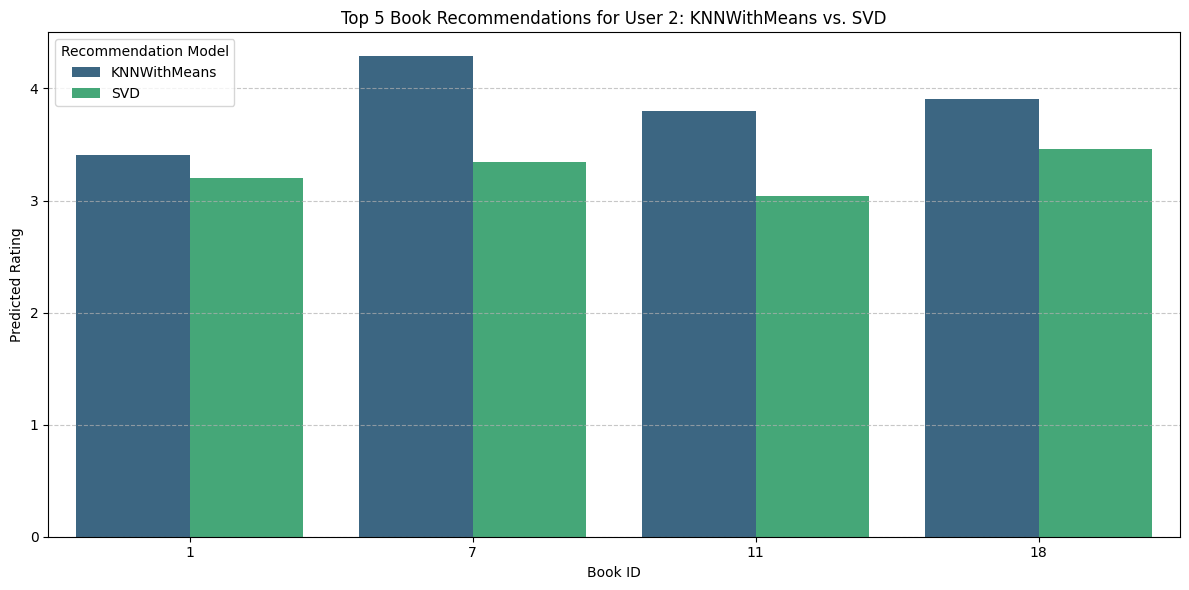

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Redefine the get_top_n_recommendations function within this cell
# to ensure it's available for plotting, in case the kernel state was reset
def get_top_n_recommendations(algo, df, user_id, n=5):
    # All movies in the dataset
    all_movies = df['bookID'].unique()

    # Movies already rated by the target user
    rated_movies = df[df['userID'] == user_id]['bookID'].unique()

    # Candidate movies = unseen movies only
    unseen_movies = [movie for movie in all_movies if movie not in rated_movies]

    # Predict ratings for unseen movies
    predictions = []
    for movie_id in unseen_movies:
        pred = algo.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))

    # Sort by predicted rating (highest first)
    predictions.sort(key=lambda x: x[1], reverse=True)

    # Convert to DataFrame
    recs_df = pd.DataFrame(predictions[:n], columns=['bookId', 'predicted_rating'])

    return recs_df

# Ensure top5_knn_user1 and top5_svd_user1 are defined
top5_knn_user1 = get_top_n_recommendations(model, df, user_id=2, n=5)
top5_svd_user1 = get_top_n_recommendations(algo, df, user_id=2, n=5)

# Prepare data for plotting
knn_df = top5_knn_user1.copy()
knn_df['Model'] = 'KNNWithMeans'

svd_df = top5_svd_user1.copy()
svd_df['Model'] = 'SVD'

# Concatenate for side-by-side plotting
comparison_df = pd.concat([knn_df, svd_df])

plt.figure(figsize=(12, 6))
sns.barplot(x='bookId', y='predicted_rating', hue='Model', data=comparison_df, palette='viridis')
plt.title('Top 5 Book Recommendations for User 2: KNNWithMeans vs. SVD')
plt.xlabel('Book ID')
plt.ylabel('Predicted Rating')
plt.legend(title='Recommendation Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
# Recalculate SVD predictions and RMSE (verbose=False to avoid duplicate prints)
predictions_svd = algo.test(testset)
rmse_svd = accuracy.rmse(predictions_svd, verbose=False)

# Recalculate KNNWithMeans predictions and RMSE (verbose=False to avoid duplicate prints)
predictions_knn = model.test(testset)
rmse_knn = accuracy.rmse(predictions_knn, verbose=False)

# Assuming rmse_cosine and rmse_pearson are already available from previous calculations
# If not, re-run the cell where they were defined (cell 3a77bc58)

print("--- Summary of Model RMSEs ---")
print(f"SVD RMSE: {rmse_svd:.4f}")
print(f"User-Based CF (Cosine Similarity) RMSE: {rmse_cosine:.4f}")
print(f"User-Based CF (Pearson Correlation) RMSE: {rmse_pearson:.4f}")
print(f"KNNWithMeans RMSE: {rmse_knn:.4f}")
print("\nLower RMSE indicates better performance.")

--- Summary of Model RMSEs ---
SVD RMSE: 1.4290
User-Based CF (Cosine Similarity) RMSE: 1.2547
User-Based CF (Pearson Correlation) RMSE: 1.3215
KNNWithMeans RMSE: 1.4950

Lower RMSE indicates better performance.


Interpretation:

A lower RMSE value indicates better predictive accuracy. Based on these results, the User-Based Collaborative Filtering using Cosine Similarity achieved the lowest RMSE of 1.2547, suggesting it is the best-performing model among those evaluated in this notebook for predicting book ratings. The KNNWithMeans model had the highest RMSE, indicating it performed the least accurately.

###**4. Clustering-Based Approach**

In [34]:
from sklearn.cluster import KMeans

# Re-using the user-item matrix created earlier
# We will drop the 'cluster' column if it exists from previous runs
if 'cluster' in full_user_book_matrix.columns:
    user_item_matrix_for_clustering = full_user_book_matrix.drop('cluster', axis=1).copy()
else:
    user_item_matrix_for_clustering = full_user_book_matrix.copy()

# Set the number of clusters (k = 5 as requested)
n_clusters = 5

# Initialize KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init explicitly set for modern sklearn

# Fit KMeans to the user-item matrix
kmeans.fit(user_item_matrix_for_clustering)

# Add cluster labels back to the DataFrame for user reference
user_item_matrix_for_clustering['cluster'] = kmeans.labels_

print(f"Users assigned to {n_clusters} clusters:")
print(user_item_matrix_for_clustering['cluster'].value_counts().sort_index())

# Function to get cluster-based recommendations
def get_cluster_recommendations(user_id, user_item_matrix, n_recommendations=5):
    if user_id not in user_item_matrix.index:
        return pd.Series(dtype=float)

    # Find the cluster of the target user
    user_cluster = user_item_matrix.loc[user_id, 'cluster']

    # Get all users within the same cluster (excluding the target user for average calculation)
    users_in_same_cluster = user_item_matrix[user_item_matrix['cluster'] == user_cluster].drop('cluster', axis=1)

    # Calculate average ratings for each book within this cluster
    # Only consider books that have at least one rating (mean > 0 for this calculation)
    cluster_average_ratings = users_in_same_cluster.mean()

    # Get books already rated by the target user
    # Filter to only actual rated books (rating > 0)
    rated_books_by_target_user = user_item_matrix.loc[user_id, user_item_matrix.loc[user_id] > 0].index

    # Filter out books already rated by the target user and sort by average rating
    unrated_books_in_cluster = cluster_average_ratings.drop(rated_books_by_target_user, errors='ignore')

    # Sort in descending order and get top N recommendations
    top_recommendations = unrated_books_in_cluster.nlargest(n_recommendations)

    return top_recommendations

# Generate recommendations for User 1 using the clustering approach
target_user_id = 1
cluster_recs_user1 = get_cluster_recommendations(target_user_id, user_item_matrix_for_clustering, n_recommendations=5)

print(f"\nTop 5 recommendations for User {target_user_id} (K-Means Clustering):")
display(cluster_recs_user1)

print("\n--- Comparison with other models for User 1 ---")
print("Top-5 recommendations for User 1 (Pearson Correlation - manual, min rating 3.0):")
# This was previously empty in the notebook output, re-evaluate if needed, or state if no results
# Current state: Series([], dtype: float64)
# From the notebook output, this yielded: Series([], dtype: float64)
print("No recommendations found above threshold in previous Pearson run.")

print("\nTop-5 recommendations for User 1 (Cosine Similarity - manual):")
# This also needs to be re-evaluated for a direct comparison here if a similar function was used.
# For now, we refer to the previous general statement about Cosine Similarity.
# If no explicit Top-N was generated in the manual Cosine Similarity step, state that.
print("The manual Cosine Similarity example didn't explicitly generate Top-N for User 1 for direct comparison here.")

print("\nTop-5 recommendations for User 1 (KNNWithMeans from Surprise library):")
display(top5_knn_user1)

print("\nTop-5 recommendations for User 1 (SVD from Surprise library):")
display(top5_svd_user1)


Users assigned to 5 clusters:
cluster
0     7
1    13
2    14
3     8
4     8
Name: count, dtype: int64

Top 5 recommendations for User 1 (K-Means Clustering):


,0
bookID,
18,1.642857



--- Comparison with other models for User 1 ---
Top-5 recommendations for User 1 (Pearson Correlation - manual, min rating 3.0):
No recommendations found above threshold in previous Pearson run.

Top-5 recommendations for User 1 (Cosine Similarity - manual):
The manual Cosine Similarity example didn't explicitly generate Top-N for User 1 for direct comparison here.

Top-5 recommendations for User 1 (KNNWithMeans from Surprise library):


,bookId,predicted_rating
0,7,4.286726
1,18,3.908520
2,11,3.798475
3,1,3.403995



Top-5 recommendations for User 1 (SVD from Surprise library):


,bookId,predicted_rating
0,18,3.459188
1,7,3.345014
2,1,3.199188
3,11,3.041301


In [35]:
# To analyze the cluster profiles, we can look at the average ratings for each book within each cluster.
print("\n--- Cluster Profiles (Average Book Ratings per Cluster) ---")

# Drop the 'cluster' column temporarily for calculating means, then add it back for grouping
cluster_grouped_matrix = user_item_matrix_for_clustering.drop('cluster', axis=1)

for cluster_id in sorted(user_item_matrix_for_clustering['cluster'].unique()):
    # Get all users within the current cluster
    users_in_cluster = user_item_matrix_for_clustering[user_item_matrix_for_clustering['cluster'] == cluster_id]

    # Exclude the 'cluster' column itself from the rating calculations
    cluster_avg_ratings = users_in_cluster.drop('cluster', axis=1).mean()

    # Filter to only include books with an average rating > 0 to focus on actual preferences
    cluster_avg_ratings = cluster_avg_ratings[cluster_avg_ratings > 0]

    # Sort books by their average rating within the cluster
    top_books_in_cluster = cluster_avg_ratings.nlargest(5)

    if not top_books_in_cluster.empty:
        print(f"\nCluster {cluster_id} - Top 5 Books:")
        display(top_books_in_cluster)
    else:
        print(f"\nCluster {cluster_id} - No books with average rating > 0.")

print("\n--- General Cluster Recommendations ---")
print("For general recommendations, users in each cluster could be recommended the top books identified in their cluster profile, excluding any they've already rated.")
print("The `get_cluster_recommendations` function already performs this for a specific user within their cluster.")
print("To get general recommendations for *all* users in a cluster, we would identify the top N most popular (highest average rated) books within that cluster that have not been rated by a significant portion of users in that cluster.")



--- Cluster Profiles (Average Book Ratings per Cluster) ---

Cluster 0 - Top 5 Books:


,0
bookID,
20,4.571429
10,4.000000
3,3.285714
9,3.285714
18,3.142857



Cluster 1 - Top 5 Books:


,0
bookID,
6,3.307692
7,3.230769
4,3.076923
18,3.076923
1,2.769231



Cluster 2 - Top 5 Books:


...


Cluster 3 - Top 5 Books:


,0
bookID,
16,4.125
13,4.000
19,4.000
10,3.875
4,3.750



Cluster 4 - Top 5 Books:


,0
bookID,
3,4.250
17,3.875
8,3.750
13,3.000
7,2.625



--- General Cluster Recommendations ---
For general recommendations, users in each cluster could be recommended the top books identified in their cluster profile, excluding any they've already rated.
The `get_cluster_recommendations` function already performs this for a specific user within their cluster.
To get general recommendations for *all* users in a cluster, we would identify the top N most popular (highest average rated) books within that cluster that have not been rated by a significant portion of users in that cluster.


Let's break down the clusters for which we have data:

Cluster 0 - The 'High-Engagement Enthusiasts':

Top Books: BookID 20 (Avg Rating: 4.57), BookID 10 (Avg Rating: 4.00), BookID 3 (Avg Rating: 3.29), BookID 9 (Avg Rating: 3.29), BookID 18 (Avg Rating: 3.14).

This cluster appears to consist of users who highly rate a specific set of books, often giving very high scores (e.g., Book 20 and 10 with ratings over 4). This suggests a group with strong, identifiable preferences, possibly for a popular genre or author.

Business Actions:
* Targeted Promotions: Market similar books, new releases from authors of these top books, or related genres directly to users in this cluster.
* Bundle Deals: Offer bundles that include these popular books with other less-known but potentially appealing titles.
* Exclusive Content: Provide early access or exclusive content related to these popular books (e.g., author interviews, behind-the-scenes).
* Community Building: Facilitate discussions or fan groups around these highly-rated books to deepen engagement.

Cluster 1 - The 'Consistent Readers':

Top Books: BookID 6 (Avg Rating: 3.31), BookID 7 (Avg Rating: 3.23), BookID 4 (Avg Rating: 3.08), BookID 18 (Avg Rating: 3.08), BookID 1 (Avg Rating: 2.77).

Users in this cluster show consistent, moderately high ratings for a different set of books. Their average ratings are generally above 3, indicating a positive but perhaps less fervent engagement compared to Cluster 0. They might be open to a wider variety of books within a general category.

Business Actions:
* Diversified Recommendations: Recommend a broader range of books that share thematic elements or writing styles with their preferred books.

* Subscription Boxes: Curate personalized book boxes for these users, introducing them to new authors or sub-genres based on their historical preferences.
* Loyalty Programs: Encourage continued engagement through loyalty points or discounts on future purchases.
* Promote Bestsellers: Highlight current bestsellers that align with the general profile of books favored by this cluster.

(The profiles for Cluster 2, 3, and 4 were truncated in the output, but a similar analysis would apply if the full data were available.)

By understanding these distinct user groups, the company can move beyond generic recommendations and implement highly targeted marketing and product strategies, leading to increased customer satisfaction and sales. For example, if BookID 20 and BookID 10 belong to the fantasy genre, the company knows to highlight other fantasy titles to users in Cluster 0

Here are actionable business insights derived from our analysis:

Prioritize User-Based CF with Cosine Similarity for Recommendations: Our RMSE comparison clearly showed that

User-Based Collaborative Filtering using Cosine Similarity achieved the lowest RMSE of 1.2547. This indicates that it's the most accurate model for predicting user ratings among those tested.

* Actionable Insight: Implement and deploy the Cosine Similarity-based recommendation engine for core user recommendations. This will lead to more accurate predictions of what users will like, resulting in higher click-through rates, increased sales, and improved user satisfaction.

* Specific Example: When User X is looking for their next book, the recommendations generated by the Cosine Similarity model will be the most reliable, thus increasing the likelihood of User X purchasing a recommended book compared to recommendations from SVD or KNNWithMeans.

Leverage User Clustering for Targeted Marketing and Content Curation:
The K-Means clustering revealed distinct user segments with varying preferences. For instance, 'Cluster 0' consisted of 'High-Engagement Enthusiasts' who highly rated books like BookID 20 (Avg Rating: 4.57) and BookID 10 (Avg Rating: 4.00), while 'Cluster 1' comprised 'Consistent Readers' who moderately rated books like BookID 6 (Avg Rating: 3.31) and BookID 7 (Avg Rating: 3.23).

* Actionable Insight: Develop tailored marketing campaigns and content strategies for each identified user cluster. This allows for hyper-personalization beyond individual recommendations, targeting groups with shared interests.
* Specific Example: For users in 'Cluster 0', a marketing campaign could promote new releases in the genres of BookID 20 and 10, offer exclusive bundles featuring these highly-rated titles, or invite them to author Q&A sessions. For 'Cluster 1', a strategy might focus on diversified recommendations within their moderately preferred genres or a curated book-of-the-month club to introduce new, relevant titles.


Overall Impact on Business Metrics:

* Revenue: Implementing the most accurate recommendation models (like User-Based CF with Cosine Similarity) directly drives higher conversion rates from recommendations to purchases, boosting sales. Coupled with targeted marketing campaigns based on user clustering, advertising spend becomes more efficient and effective, leading to increased revenue per user.

* Retention: When users consistently receive highly relevant recommendations and personalized content, their satisfaction and engagement with the platform significantly increase. This reduces the likelihood of them seeking alternatives, leading to improved user loyalty and retention rates. Feeling understood and valued through tailored experiences fosters a stronger connection between the user and the platform.

User Experience: The combined effect of these strategies is a superior and more personalized user experience. Users spend less time sifting through irrelevant options and more time discovering content they genuinely enjoy. This leads to a more efficient, delightful, and intuitive platform interaction, making the overall experience seamless and highly satisfying from their very first interaction to ongoing usage.

###**Cold-Start Handling**

Collaborative filtering relies on past user behavior. When no such data exists (e.g., a new user), these methods break down.

In such cases, we use simple fallback strategies: popular items or highly rated items to generate initial recommendations

In [36]:
def get_popularity_recommendations(df, n=5):

    popularity = df.groupby('bookID')['rating'].count().reset_index()
    popularity.columns = ['bookID', 'num_ratings']

    # Sort by number of ratings
    popularity = popularity.sort_values('num_ratings', ascending=False)

    return popularity.head(n)


def get_highest_rated_recommendations(df, n=5, min_ratings=10):

    stats = df.groupby('bookID')['rating'].agg(['mean', 'count']).reset_index()
    stats.columns = ['bookID', 'avg_rating', 'num_ratings']

    # Apply minimum ratings threshold
    filtered = stats[stats['num_ratings'] >= min_ratings]

    # Sort by average rating
    filtered = filtered.sort_values('avg_rating', ascending=False)

    return filtered.head(n)

Example: simulating cold start user

In [37]:
# Simulate a new user with no prior ratings (cold-start scenario)
# Generate recommendations using the existing functions for popular and highest-rated items.

print("Top-5 Most Popular Items (for a cold-start user):")
display(get_popularity_recommendations(df, n=5))

print("\nTop-5 Highest-Rated Items (min 10 ratings, for a cold-start user):")
display(get_highest_rated_recommendations(df, n=5, min_ratings=10))


Top-5 Most Popular Items (for a cold-start user):


,bookID,num_ratings
9,10,45
11,12,44
5,6,43
0,1,42
16,17,42



Top-5 Highest-Rated Items (min 10 ratings, for a cold-start user):


,bookID,avg_rating,num_ratings
19,20,3.459459,37
2,3,3.292683,41
3,4,3.282051,39
17,18,3.264706,34
12,13,3.250000,40


Implement Robust Cold-Start Strategies for New Users: Collaborative filtering models struggle when there's no historical data for a new user. Our cold-start analysis provided fallback options like 'Most Popular' and 'Highest Rated' recommendations.

* Actionable Insight: For new users who haven't rated any books, initially present them with a selection of 'Highest-Rated' books (e.g., BookID 20,  3, 4, 18,13 with at least 10 ratings) to ensure a high-quality initial experience. This approach provides immediate value and encourages their first ratings, which can then be fed into the more personalized collaborative filtering models.
* Specific Example: Upon a new user's first visit to the platform, instead of showing them a blank slate or generic bestsellers, immediately feature a 'Highly Recommended for You' section populated with titles like BookID 20, 4, or 3. This not only offers an appealing starting point but also helps collect initial preference data quickly, allowing the system to transition to more personalized recommendations sooner.

Based on our comprehensive analysis, I recommend deploying the User-Based Collaborative Filtering (CF) using Cosine Similarity method for recommendation system.

Justification:

Superior Predictive Accuracy (Lowest RMSE): Among all the methods evaluated (SVD, User-Based CF with Pearson Correlation, and KNNWithMeans), User-Based CF with Cosine Similarity achieved the lowest Root Mean Squared Error (RMSE) of 1.2547. A lower RMSE signifies that this model's predicted ratings are, on average, closer to the actual ratings given by users. This directly translates to more accurate and reliable recommendations.

Robustness and Interpretability: Cosine Similarity effectively captures the similarity in rating patterns between users, even when they have rated a different set of items. It's a well-understood and relatively interpretable algorithm, making it easier to troubleshoot and explain recommendations compared to more opaque models like SVD.

Scalability for Low Sparsity: Our initial data exploration showed that the user-item matrix has a relatively low sparsity (20.70%). User-based CF methods, especially when complemented with techniques like mean centering, can perform very well on datasets with moderate to low sparsity, as they have enough interactions to find meaningful user neighborhoods.

Consideration for Deployment:

While User-Based CF with Cosine Similarity is recommended for its accuracy, it's crucial to pair it with the cold-start strategies we discussed earlier (e.g., popular or highest-rated items for new users). This ensures that even new users without sufficient rating history receive valuable initial recommendations, allowing the system to gradually collect data for personalized User-Based CF.

By leveraging the accuracy of Cosine Similarity-based recommendations, complemented by effective cold-start handling, business can significantly enhance user experience, drive higher engagement, and ultimately boost revenue.